<a href="https://colab.research.google.com/github/11465005-tech/ChineseEmoBank_ValenceArousal/blob/main/chinese_pipelined_bert_pipeline_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 中文版 Pipelined Neural Networks v7 — BERT 遞迴 Pipeline

## 和 v5（BERT 多任務共用 encoder）的差異

| 項目 | v5（多任務共用 encoder）| **v7（BERT 遞迴 Pipeline）**|
|------|------------------------|----------------------------|
| BERT 角色 | 共用 encoder，Word/Phrase 平行輸入 | **每個詞/修飾詞各自獨立 encode** |
| 串接方式 | 梯度共享更新 BERT | **輸出值遞迴傳遞（對應論文 Fig. 4）**|
| NNmod | 無（直接 phrase_head 輸出）| **保留殘差移位 NNmod** |
| 多修飾詞 | 整串片語一次 encode | **逐層遞迴：mod₃→mod₂→mod₁** |

## 架構設計
```
「開心」→ BERT [CLS] → 768 維 → NNword head → Int(w) = 0.81
                                                    ↓
「非常」→ BERT [CLS] → 768 維 → NNmod → Int(非常開心) = 0.89
                                              ↓
「沒有」→ BERT [CLS] → 768 維 → NNmod → Int(沒有非常開心) = 0.43
```


## 0. 安裝套件

In [ ]:
!pip install transformers torch numpy pandas scikit-learn matplotlib scipy -q

## 1. 掛載 Google Drive 並載入資料集

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau, spearmanr, pearsonr
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

# ---- 路徑設定（和你原本 notebook 相同）----
CVAW_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAW_SD/CVAW_all_SD.csv'
CVAP_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAP_SD/CVAP_all_SD.csv'
CVAT_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAT_SD/CVAT_all_SD.csv'

def read_csv_robust(path, sep='\t'):
    for enc in ['utf-8', 'utf-8-sig', 'big5', 'gb18030', 'cp950']:
        try:
            df = pd.read_csv(path, sep=sep, encoding=enc)
            print(f'  → {path.split("/")[-1]} 使用編碼: {enc}')
            return df
        except (UnicodeDecodeError, UnicodeError):
            continue
    return pd.read_csv(path, sep=sep, encoding='utf-8', encoding_errors='replace')

cvaw = read_csv_robust(CVAW_PATH)
cvap = read_csv_robust(CVAP_PATH)
cvat = read_csv_robust(CVAT_PATH)
print(f'CVAW: {len(cvaw)}  CVAP: {len(cvap)}  CVAT: {len(cvat)}')

使用裝置: cuda
  → CVAW_all_SD.csv 使用編碼: utf-8
  → CVAP_all_SD.csv 使用編碼: utf-8
CVAW: 5512  CVAP: 2250  CVAT: 2971


## 2. 資料前處理

In [ ]:
def normalize_va(df, val_col='Valence_Mean', aro_col='Arousal_Mean'):
    df = df.copy()
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    df[aro_col] = pd.to_numeric(df[aro_col], errors='coerce')
    before = len(df)
    df = df.dropna(subset=[val_col, aro_col]).reset_index(drop=True)
    if before - len(df) > 0:
        print(f'  ⚠ 清除 {before-len(df)} 筆髒資料')
    df['valence'] = (df[val_col] - 1) / 8.0
    df['arousal'] = (df[aro_col] - 1) / 8.0
    return df

cvaw = normalize_va(cvaw)
cvap = normalize_va(cvap)
cvat = normalize_va(cvat)

# CVAP 短語切割：修飾詞 + 核心詞
cvaw_word_set = set(cvaw['Word'].tolist())

def split_phrase(phrase, cvaw_words):
    for mod_len in [1, 2, 3, 4]:
        if len(phrase) > mod_len:
            mod  = phrase[:mod_len]
            core = phrase[mod_len:]
            if core in cvaw_words:
                return mod, core
    return None, None

mods, cores = [], []
for phrase in cvap['Phrase']:
    m, c = split_phrase(phrase, cvaw_word_set)
    mods.append(m); cores.append(c)
cvap['modifier']  = mods
cvap['core_word'] = cores
cvap_aligned = cvap.dropna(subset=['modifier','core_word']).copy()
print(f'CVAP 對齊: {len(cvap_aligned)} / {len(cvap)} 筆')

# 8:2 切分
cvaw_train, cvaw_test = train_test_split(cvaw,         test_size=0.2, random_state=42)
cvap_train, cvap_test = train_test_split(cvap_aligned, test_size=0.2, random_state=42)
print(f'CVAW 訓練:{len(cvaw_train)}  測試:{len(cvaw_test)}')
print(f'CVAP 訓練:{len(cvap_train)}  測試:{len(cvap_test)}')

  ⚠ 清除 1 筆髒資料
CVAP 對齊: 2249 / 2250 筆
CVAW 訓練:4409  測試:1103
CVAP 訓練:1799  測試:450


## 3. 載入中文 BERT
用 BERT [CLS] 向量取代原本的 Word2Vec，  
對每個詞/修飾詞各自獨立 encode，解決 kNN 對未知詞向量品質不穩的問題。

In [ ]:
BERT_NAME = 'hfl/chinese-bert-wwm-ext'

print(f'載入 {BERT_NAME}（約需 1~2 分鐘）...')
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model = AutoModel.from_pretrained(BERT_NAME).to(device)
BERT_DIM = bert_model.config.hidden_size
print(f'✅ 載入完成 | hidden size: {BERT_DIM}')

@torch.no_grad()
def get_bert_vec(text):
    """
    v7 核心改動：用 BERT [CLS] 取代 Word2Vec。
    BERT 對任何詞/修飾詞都能產生 768 維的語意向量，
    包含上下文資訊，不需要靠 kNN 鄰居補救。
    """
    bert_model.eval()
    enc = tokenizer(
        text, return_tensors='pt',
        padding=True, truncation=True, max_length=16
    ).to(device)
    out = bert_model(**enc)
    # [CLS] token 的輸出代表整個輸入的語意
    cls_vec = out.last_hidden_state[:, 0, :].squeeze(0)
    return cls_vec.cpu().numpy().astype(np.float32)

# 批次版本（訓練時效率更高）
@torch.no_grad()
def get_bert_vecs_batch(texts, batch_size=64):
    bert_model.eval()
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch, return_tensors='pt',
            padding=True, truncation=True, max_length=16
        ).to(device)
        out = bert_model(**enc)
        cls = out.last_hidden_state[:, 0, :]
        all_vecs.append(cls.cpu().numpy())
    return np.concatenate(all_vecs, axis=0).astype(np.float32)

# 測試
v1 = get_bert_vec('開心')
v2 = get_bert_vec('難過')
v3 = get_bert_vec('非常')
sim_happy_sad = float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
print(f'開心 vs 難過 cosine: {sim_happy_sad:.4f}')
print(f'BERT 向量維度: {v1.shape}')

載入 hfl/chinese-bert-wwm-ext（約需 1~2 分鐘）...


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  412MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hfl/chinese-bert-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 載入完成 | hidden size: 768
開心 vs 難過 cosine: 0.8179
BERT 向量維度: (768,)


## 4. 模型定義

### NNword head：BERT 向量 → VA 值
取代原本「種子詞相似度加權」的 NNword，  
直接把 BERT [CLS] 向量映射成 Valence / Arousal。

### NNmod：修飾詞移位（保留原本殘差結構）
輸入改為 BERT 向量（768維），其他邏輯不變。

In [ ]:
class NNword(nn.Module):
    """
    v7 版 NNword：BERT [CLS] → Valence / Arousal
    取代原本的相似度加權架構，避免 kNN 退化問題。
    輸入：BERT 768 維向量（單詞）
    輸出：val, aro ∈ [0,1]
    """
    def __init__(self, bert_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bert_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)      # [valence, arousal]
        )

    def forward(self, bert_vec):
        # bert_vec: (batch, 768)
        out = torch.sigmoid(self.net(bert_vec))
        return out[:, 0:1], out[:, 1:2]  # valence, arousal


class NNmod(nn.Module):
    """
    v7 版 NNmod：殘差移位（和 v4/v5 相同邏輯，輸入維度改為 768）
    輸入：Int_val(w), Int_aro(w)（NNword 輸出）+ BERT 修飾詞向量（768維）
    隱藏：delta = tanh(fc2(BN(fc1(bert_mod)))) * 0.5 ← 有方向的移位量
    輸出：Int(mod w) = sigmoid(logit(Int(w)) + delta * 3)
    """
    def __init__(self, bert_dim=768):
        super().__init__()
        self.fc1 = nn.Linear(bert_dim, 128)
        self.fc2 = nn.Linear(128, 2)     # [delta_val, delta_aro]
        self.bn  = nn.BatchNorm1d(128)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, int_val, int_aro, bert_mod):
        # bert_mod: (batch, 768)
        h       = torch.relu(self.bn(self.fc1(bert_mod)))
        delta   = torch.tanh(self.fc2(h)) * 0.5
        delta_v = delta[:, 0:1]
        delta_a = delta[:, 1:2]
        # logit 空間加移位 → sigmoid 壓回 [0,1]
        out_v   = torch.sigmoid(torch.logit(int_val.clamp(0.01, 0.99)) + delta_v * 3)
        out_a   = torch.sigmoid(torch.logit(int_aro.clamp(0.01, 0.99)) + delta_a * 3)
        c_mod   = (delta_v + 0.5)  # 顯示用（0=最大削弱，1=最大加強）
        return out_v, out_a, c_mod

print('NNword / NNmod 定義完成')

NNword / NNmod 定義完成


## 5. 預先計算所有 BERT 向量
BERT encode 比 Word2Vec 慢，所以訓練前先把所有詞/修飾詞的向量算好快取。

In [ ]:
print('預先計算 CVAW 訓練集詞向量...')
word_train_vecs = get_bert_vecs_batch(cvaw_train['Word'].tolist())
word_train_val  = cvaw_train['valence'].values.astype(np.float32)
word_train_aro  = cvaw_train['arousal'].values.astype(np.float32)

print('預先計算 CVAW 測試集詞向量...')
word_test_vecs  = get_bert_vecs_batch(cvaw_test['Word'].tolist())
word_test_val   = cvaw_test['valence'].values.astype(np.float32)
word_test_aro   = cvaw_test['arousal'].values.astype(np.float32)

print('預先計算 CVAP 訓練集核心詞 + 修飾詞向量...')
core_train_vecs = get_bert_vecs_batch(cvap_train['core_word'].tolist())
mod_train_vecs  = get_bert_vecs_batch(cvap_train['modifier'].tolist())
phrase_train_val= cvap_train['valence'].values.astype(np.float32)
phrase_train_aro= cvap_train['arousal'].values.astype(np.float32)

print('預先計算 CVAP 測試集核心詞 + 修飾詞向量...')
core_test_vecs  = get_bert_vecs_batch(cvap_test['core_word'].tolist())
mod_test_vecs   = get_bert_vecs_batch(cvap_test['modifier'].tolist())
phrase_test_val = cvap_test['valence'].values.astype(np.float32)
phrase_test_aro = cvap_test['arousal'].values.astype(np.float32)

# 轉成 PyTorch 張量
wt_v = torch.tensor(word_train_vecs).to(device)
wt_y_v = torch.tensor(word_train_val).unsqueeze(1).to(device)
wt_y_a = torch.tensor(word_train_aro).unsqueeze(1).to(device)

ct_v = torch.tensor(core_train_vecs).to(device)
mt_v = torch.tensor(mod_train_vecs).to(device)
pt_y_v = torch.tensor(phrase_train_val).unsqueeze(1).to(device)
pt_y_a = torch.tensor(phrase_train_aro).unsqueeze(1).to(device)

print(f'詞訓練: {wt_v.shape}  片語訓練: {ct_v.shape}  修飾詞: {mt_v.shape}')

預先計算 CVAW 訓練集詞向量...
預先計算 CVAW 測試集詞向量...
預先計算 CVAP 訓練集核心詞 + 修飾詞向量...
預先計算 CVAP 測試集核心詞 + 修飾詞向量...
詞訓練: torch.Size([4409, 768])  片語訓練: torch.Size([1799, 768])  修飾詞: torch.Size([1799, 768])


## 6. Stage 1：訓練 NNword（BERT 向量 → VA）

=== Stage 1：訓練 NNword ===
Epoch  10/50 | Loss: 0.005438
Epoch  20/50 | Loss: 0.003058
Epoch  30/50 | Loss: 0.002125
Epoch  40/50 | Loss: 0.001356
Epoch  50/50 | Loss: 0.001275


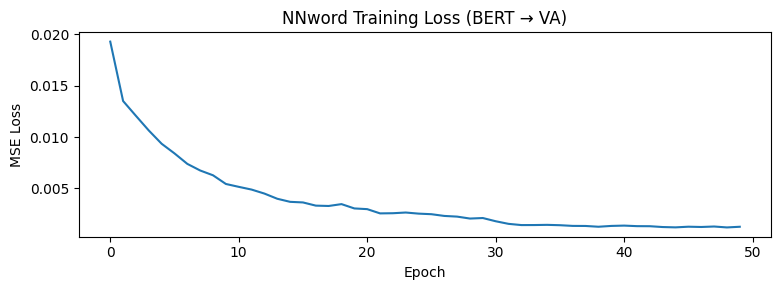

Stage 1 完成


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

model_word = NNword(BERT_DIM).to(device)
opt_word   = optim.AdamW(model_word.parameters(), lr=1e-3, weight_decay=0.01)
sch_word   = optim.lr_scheduler.StepLR(opt_word, step_size=30, gamma=0.5)

# DataLoader（batch training 讓 BatchNorm 正常運作）
word_ds = TensorDataset(wt_v, wt_y_v, wt_y_a)
word_dl = DataLoader(word_ds, batch_size=64, shuffle=True)

print('=== Stage 1：訓練 NNword ===')
N_EPOCHS_WORD = 50
losses_w = []

for epoch in range(N_EPOCHS_WORD):
    model_word.train()
    epoch_loss = 0.0
    for bvec, by_v, by_a in word_dl:
        pred_v, pred_a = model_word(bvec)
        loss = 0.5 * ((pred_v - by_v)**2 + (pred_a - by_a)**2).mean()
        opt_word.zero_grad()
        loss.backward()
        opt_word.step()
        epoch_loss += loss.item()
    sch_word.step()
    avg = epoch_loss / len(word_dl)
    losses_w.append(avg)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS_WORD} | Loss: {avg:.6f}')

plt.figure(figsize=(8,3))
plt.plot(losses_w)
plt.title('NNword Training Loss (BERT → VA)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Stage 1 完成')

## 7. Stage 2：訓練 NNmod（NNword 凍結，Pipeline 串接）

**v7 的 Pipeline 串接流程：**
1. NNword(BERT(core_word)) → Int(w)  ← BERT 取代 Word2Vec+kNN
2. NNmod(Int(w), BERT(modifier)) → Int(mod w)  ← 殘差移位

NNword 凍結，只訓練 NNmod，避免梯度帶壞 NNword 已學到的能力。

=== Stage 2：訓練 NNmod（NNword 凍結，BERT Pipeline）===
流程：BERT(core) → NNword → Int(w) → NNmod ← BERT(mod)
Epoch  20/100 | Loss: 0.020067
Epoch  40/100 | Loss: 0.020068
Epoch  60/100 | Loss: 0.019717
Epoch  80/100 | Loss: 0.019532
Epoch 100/100 | Loss: 0.019430


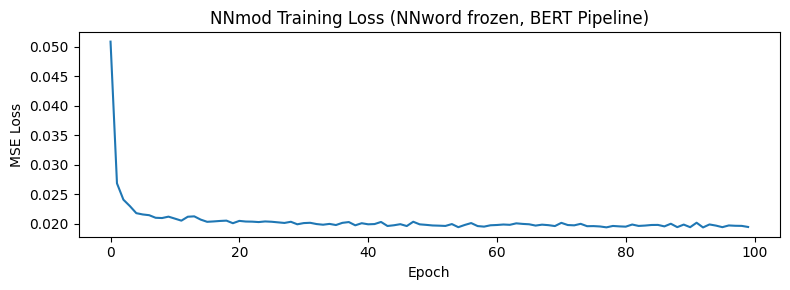

Stage 2 完成


In [ ]:
model_mod = NNmod(BERT_DIM).to(device)

# 凍結 NNword
for param in model_word.parameters():
    param.requires_grad = False

opt_mod = optim.AdamW(model_mod.parameters(), lr=5e-3, weight_decay=1e-4)

# DataLoader
phrase_ds = TensorDataset(ct_v, mt_v, pt_y_v, pt_y_a)
phrase_dl = DataLoader(phrase_ds, batch_size=32, shuffle=True)

print('=== Stage 2：訓練 NNmod（NNword 凍結，BERT Pipeline）===')
print('流程：BERT(core) → NNword → Int(w) → NNmod ← BERT(mod)')
N_EPOCHS_MOD = 100
losses_m = []

for epoch in range(N_EPOCHS_MOD):
    model_mod.train()
    model_word.eval()  # 凍結後設 eval
    epoch_loss = 0.0

    for b_core, b_mod, b_y_v, b_y_a in phrase_dl:
        # ── Pipeline 串接核心 ──
        # Step 1：NNword 用核心詞的 BERT 向量輸出 Int(w)
        with torch.no_grad():
            int_val, int_aro = model_word(b_core)

        # Step 2：NNmod 接收 Int(w) 和修飾詞的 BERT 向量
        pred_v, pred_a, _ = model_mod(int_val, int_aro, b_mod)
        loss = 0.5 * ((pred_v - b_y_v)**2 + (pred_a - b_y_a)**2).mean()

        opt_mod.zero_grad()
        loss.backward()
        opt_mod.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(phrase_dl)
    losses_m.append(avg)
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS_MOD} | Loss: {avg:.6f}')

plt.figure(figsize=(8,3))
plt.plot(losses_m)
plt.title('NNmod Training Loss (NNword frozen, BERT Pipeline)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('Stage 2 完成')

## 8. 預測函式

In [ ]:
@torch.no_grad()
def predict_word_va(word):
    """
    單詞 VA 預測：BERT encode → NNword → (valence, arousal)
    v7 改動：不再查表也不用 kNN，每個詞都走 BERT+NNword
    """
    model_word.eval()
    vec = torch.tensor(get_bert_vec(word)).unsqueeze(0).to(device)
    val, aro = model_word(vec)
    return val.item(), aro.item()


@torch.no_grad()
def predict_phrase_va_pipeline(modifier, core_word, verbose=False):
    """
    完整 Pipeline 預測（對應論文 Fig. 4 單層）：
    BERT(core_word) → NNword → Int(w)
                                  ↓
    BERT(modifier)  → NNmod → Int(mod w)
    """
    model_word.eval()
    model_mod.eval()

    # Step 1：核心詞 BERT encode → NNword → Int(w)
    core_vec = torch.tensor(get_bert_vec(core_word)).unsqueeze(0).to(device)
    int_val, int_aro = model_word(core_vec)

    # Step 2：修飾詞 BERT encode → NNmod → Int(mod w)
    mod_vec = torch.tensor(get_bert_vec(modifier)).unsqueeze(0).to(device)
    pred_v, pred_a, c_mod = model_mod(int_val, int_aro, mod_vec)

    pv, pa = pred_v.item(), pred_a.item()
    iv, ia = int_val.item(), int_aro.item()
    cm     = c_mod.item()

    if verbose:
        print(f'「{modifier}{core_word}」'
              f'  BERT+NNword→V={iv:.3f},A={ia:.3f}'
              f'  C(mod)={cm:.3f}'
              f'  → V={pv:.4f} A={pa:.4f}')
    return pv, pa


def va_label(v, a):
    pol = '正向' if v>=0.625 else ('負向' if v<=0.375 else '中性')
    act = '高喚起' if a>=0.625 else ('低喚起' if a<=0.375 else '中喚起')
    return f'{pol}/{act}'


# 測試預測
print('=== 單詞預測 ===')
for w in ['開心','難過','憤怒','平靜','興奮','恐懼']:
    v, a = predict_word_va(w)
    print(f'「{w}」V={v:.4f} A={a:.4f} → {va_label(v,a)}')

print()
print('=== Pipeline 片語預測 ===')
for mod, word in [('非常','開心'),('沒有','希望'),('完全','不滿意'),
                  ('極為','不安'),('相當','平靜'),('可能','失望')]:
    pv, pa = predict_phrase_va_pipeline(mod, word, verbose=True)
    print(f'  → {va_label(pv, pa)}')

=== 單詞預測 ===
「開心」V=0.7959 A=0.7084 → 正向/高喚起
「難過」V=0.2728 A=0.6096 → 負向/中喚起
「憤怒」V=0.1979 A=0.7824 → 負向/高喚起
「平靜」V=0.6744 A=0.1462 → 正向/低喚起
「興奮」V=0.8201 A=0.7775 → 正向/高喚起
「恐懼」V=0.2213 A=0.7502 → 負向/高喚起

=== Pipeline 片語預測 ===
「非常開心」  BERT+NNword→V=0.796,A=0.708  C(mod)=0.528  → V=0.8092 A=0.8647
  → 正向/高喚起
「沒有希望」  BERT+NNword→V=0.730,A=0.496  C(mod)=0.286  → V=0.5876 A=0.4293
  → 中性/中喚起
「完全不滿意」  BERT+NNword→V=0.371,A=0.434  C(mod)=0.501  → V=0.3715 A=0.5800
  → 負向/中喚起
「極為不安」  BERT+NNword→V=0.330,A=0.571  C(mod)=0.453  → V=0.2998 A=0.7441
  → 負向/高喚起
「相當平靜」  BERT+NNword→V=0.674,A=0.146  C(mod)=0.479  → V=0.6603 A=0.2408
  → 正向/低喚起
「可能失望」  BERT+NNword→V=0.245,A=0.625  C(mod)=0.536  → V=0.2653 A=0.5231
  → 負向/中喚起


## 9. 多修飾詞遞迴預測（論文 Fig. 4）

每層的輸出 VA 值傳入下一層，逐層套用修飾詞，  
每個修飾詞都用 BERT 獨立 encode，對應圖中的 mod₃→mod₂→mod₁ 遞迴架構。

In [ ]:
@torch.no_grad()
def predict_multi_mod_pipeline(modifiers, core_word):
    """
    多修飾詞遞迴 Pipeline（對應論文 Fig. 4）：
    由最靠近核心詞的修飾詞（列表最右）開始，逐層向外套用。

    e.g. ['應該','沒有','非常'] + '開心'
      → BERT(開心)→NNword → Int(開心)
      → BERT(非常)→NNmod  → Int(非常開心)    [mod₃]
      → BERT(沒有)→NNmod  → Int(沒有非常開心) [mod₂]
      → BERT(應該)→NNmod  → Int(應該沒有非常開心) [mod₁]
    """
    model_word.eval()
    model_mod.eval()

    phrase_str = ''.join(modifiers) + core_word
    print(f'\n多修飾詞遞迴：「{phrase_str}」')

    # 第一步：核心詞走 BERT + NNword
    core_vec = torch.tensor(get_bert_vec(core_word)).unsqueeze(0).to(device)
    cur_v, cur_a = model_word(core_vec)
    print(f'  核心詞「{core_word}」→ V={cur_v.item():.4f} A={cur_a.item():.4f}')

    cur_label = core_word

    # 從最靠近核心詞的修飾詞開始，逐層向外（reversed）
    for i, mod in enumerate(reversed(modifiers)):
        mod_vec = torch.tensor(get_bert_vec(mod)).unsqueeze(0).to(device)
        new_v, new_a, c_mod = model_mod(cur_v, cur_a, mod_vec)

        print(f'  +「{mod}」[mod_{len(modifiers)-i}] '
              f'V:{cur_v.item():.4f}→{new_v.item():.4f}  '
              f'A:{cur_a.item():.4f}→{new_a.item():.4f}  '
              f'[C={c_mod.item():.3f}]')

        cur_v, cur_a = new_v, new_a
        cur_label = mod + cur_label

    final_v, final_a = cur_v.item(), cur_a.item()
    print(f'  最終「{phrase_str}」→ V={final_v:.4f} A={final_a:.4f}  {va_label(final_v, final_a)}')
    return final_v, final_a


# 測試（對應論文 Fig. 4 的 would not very good）
predict_multi_mod_pipeline(['應該','沒有','非常'], '開心')
predict_multi_mod_pipeline(['完全','不'],          '滿意')
predict_multi_mod_pipeline(['可能','更加'],        '不安')


多修飾詞遞迴：「應該沒有非常開心」
  核心詞「開心」→ V=0.7959 A=0.7084
  +「非常」[mod_3] V:0.7959→0.8092  A:0.7084→0.8647  [C=0.528]
  +「沒有」[mod_2] V:0.8092→0.6904  A:0.8647→0.8300  [C=0.286]
  +「應該」[mod_1] V:0.6904→0.6836  A:0.8300→0.7979  [C=0.489]
  最終「應該沒有非常開心」→ V=0.6836 A=0.7979  正向/高喚起

多修飾詞遞迴：「完全不滿意」
  核心詞「滿意」→ V=0.7029 A=0.4389
  +「不」[mod_2] V:0.7029→0.3530  A:0.4389→0.4037  [C=0.011]
  +「完全」[mod_1] V:0.3530→0.3537  A:0.4037→0.5498  [C=0.501]
  最終「完全不滿意」→ V=0.3537 A=0.5498  負向/中喚起

多修飾詞遞迴：「可能更加不安」
  核心詞「不安」→ V=0.3299 A=0.5715
  +「更加」[mod_2] V:0.3299→0.3368  A:0.5715→0.6593  [C=0.510]
  +「可能」[mod_1] V:0.3368→0.3616  A:0.6593→0.5605  [C=0.536]
  最終「可能更加不安」→ V=0.3616 A=0.5605  負向/中喚起


(0.3615918457508087, 0.5604653358459473)

## 10. 評估函式

In [ ]:
def compute_metrics(preds, golds, label):
    """
    Chinese EmoBank 論文指標：MAE、Pearson r
    Pipelined NN 論文指標：Kendall τ、Spearman ρ
    額外：MSE
    """
    p = np.array(preds); g = np.array(golds)
    mae    = np.mean(np.abs(p - g))
    mse    = np.mean((p - g) ** 2)
    r, _   = pearsonr(p, g)
    tau, _ = kendalltau(p, g)
    rho, _ = spearmanr(p, g)
    print(f'  {label:30s} | MAE={mae:.4f}  MSE={mse:.4f}  r={r:.4f}  τ={tau:.4f}  ρ={rho:.4f}')
    return mae, mse, r, tau, rho


@torch.no_grad()
def batch_predict_word(vecs_np):
    model_word.eval()
    t = torch.tensor(vecs_np).to(device)
    pv, pa = model_word(t)
    return pv.cpu().numpy().flatten(), pa.cpu().numpy().flatten()


@torch.no_grad()
def batch_predict_phrase(core_vecs_np, mod_vecs_np, batch_size=64):
    model_word.eval(); model_mod.eval()
    all_pv, all_pa = [], []
    n = len(core_vecs_np)
    for i in range(0, n, batch_size):
        bc = torch.tensor(core_vecs_np[i:i+batch_size]).to(device)
        bm = torch.tensor(mod_vecs_np[i:i+batch_size]).to(device)
        iv, ia = model_word(bc)
        pv, pa, _ = model_mod(iv, ia, bm)
        all_pv.append(pv.cpu().numpy())
        all_pa.append(pa.cpu().numpy())
    return np.concatenate(all_pv).flatten(), np.concatenate(all_pa).flatten()

## 11. 訓練集評估

In [ ]:
print('='*75)
print('【訓練集評估】')
print('='*75)

# NNword 訓練集
print('\n[NNword] CVAW 訓練集')
pv_trw, pa_trw = batch_predict_word(word_train_vecs)
compute_metrics(pv_trw, word_train_val, 'Valence')
compute_metrics(pa_trw, word_train_aro, 'Arousal')

# Pipeline 訓練集
print('\n[Pipeline] CVAP 訓練集')
pv_trm, pa_trm = batch_predict_phrase(core_train_vecs, mod_train_vecs)
compute_metrics(pv_trm, phrase_train_val, 'Valence')
compute_metrics(pa_trm, phrase_train_aro, 'Arousal')

【訓練集評估】

[NNword] CVAW 訓練集
  Valence                        | MAE=0.0164  MSE=0.0004  r=0.9952  τ=0.9430  ρ=0.9937
  Arousal                        | MAE=0.0191  MSE=0.0006  r=0.9915  τ=0.9317  ρ=0.9917

[Pipeline] CVAP 訓練集
  Valence                        | MAE=0.1302  MSE=0.0295  r=0.6860  τ=0.4635  ρ=0.6302
  Arousal                        | MAE=0.0690  MSE=0.0084  r=0.8474  τ=0.6575  ρ=0.8408


(np.float32(0.06895618),
 np.float32(0.00839892),
 np.float32(0.8473904),
 np.float64(0.6574668561424613),
 np.float64(0.8408009379822446))

## 12. 測試集評估

In [ ]:
print('='*75)
print('【測試集評估】')
print('='*75)

# NNword 測試集
print('\n[NNword] CVAW 測試集')
pv_tew, pa_tew = batch_predict_word(word_test_vecs)
compute_metrics(pv_tew, word_test_val, 'Valence')
compute_metrics(pa_tew, word_test_aro, 'Arousal')

# Pipeline 測試集
print('\n[Pipeline] CVAP 測試集')
pv_tem, pa_tem = batch_predict_phrase(core_test_vecs, mod_test_vecs)
compute_metrics(pv_tem, phrase_test_val, 'Valence')
compute_metrics(pa_tem, phrase_test_aro, 'Arousal')

【測試集評估】

[NNword] CVAW 測試集
  Valence                        | MAE=0.0752  MSE=0.0101  r=0.8711  τ=0.6571  ρ=0.8430
  Arousal                        | MAE=0.1105  MSE=0.0202  r=0.6266  τ=0.4401  ρ=0.6084

[Pipeline] CVAP 測試集
  Valence                        | MAE=0.1418  MSE=0.0361  r=0.6156  τ=0.4228  ρ=0.5667
  Arousal                        | MAE=0.0700  MSE=0.0083  r=0.8659  τ=0.6821  ρ=0.8642


(np.float32(0.06995636),
 np.float32(0.008276588),
 np.float32(0.8659317),
 np.float64(0.6820995199036679),
 np.float64(0.8641961907386894))

## 13. 結果摘要表 + 視覺化

In [ ]:
def metrics(p, g):
    pa = np.array(p); ga = np.array(g)
    mae    = np.mean(np.abs(pa - ga))
    mse    = np.mean((pa - ga)**2)
    r, _   = pearsonr(pa, ga)
    tau, _ = kendalltau(pa, ga)
    rho, _ = spearmanr(pa, ga)
    return round(mae,4), round(mse,4), round(r,4), round(tau,4), round(rho,4)

rows = [
    ('NNword',   '訓練', 'Valence', *metrics(pv_trw, word_train_val)),
    ('NNword',   '訓練', 'Arousal', *metrics(pa_trw, word_train_aro)),
    ('NNword',   '測試', 'Valence', *metrics(pv_tew, word_test_val)),
    ('NNword',   '測試', 'Arousal', *metrics(pa_tew, word_test_aro)),
    ('Pipeline', '訓練', 'Valence', *metrics(pv_trm, phrase_train_val)),
    ('Pipeline', '訓練', 'Arousal', *metrics(pa_trm, phrase_train_aro)),
    ('Pipeline', '測試', 'Valence', *metrics(pv_tem, phrase_test_val)),
    ('Pipeline', '測試', 'Arousal', *metrics(pa_tem, phrase_test_aro)),
]
summary = pd.DataFrame(rows,
    columns=['模型','資料集','維度','MAE','MSE','Pearson r','Kendall τ','Spearman ρ'])
print(summary.to_string(index=False))

      模型 資料集      維度    MAE    MSE  Pearson r  Kendall τ  Spearman ρ
  NNword  訓練 Valence 0.0164 0.0004     0.9952     0.9430      0.9937
  NNword  訓練 Arousal 0.0191 0.0006     0.9915     0.9317      0.9917
  NNword  測試 Valence 0.0752 0.0101     0.8711     0.6571      0.8430
  NNword  測試 Arousal 0.1105 0.0202     0.6266     0.4401      0.6084
Pipeline  訓練 Valence 0.1302 0.0295     0.6860     0.4635      0.6302
Pipeline  訓練 Arousal 0.0690 0.0084     0.8474     0.6575      0.8408
Pipeline  測試 Valence 0.1418 0.0361     0.6156     0.4228      0.5667
Pipeline  測試 Arousal 0.0700 0.0083     0.8659     0.6821      0.8642


/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 34253 (\N{CJK UNIFIED IDEOGRAPH-85CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18: UserWarning: Glyph 32005 (\N{CJK UNIFIED IDEOGRAPH-7D05}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_410/178586446.py:18

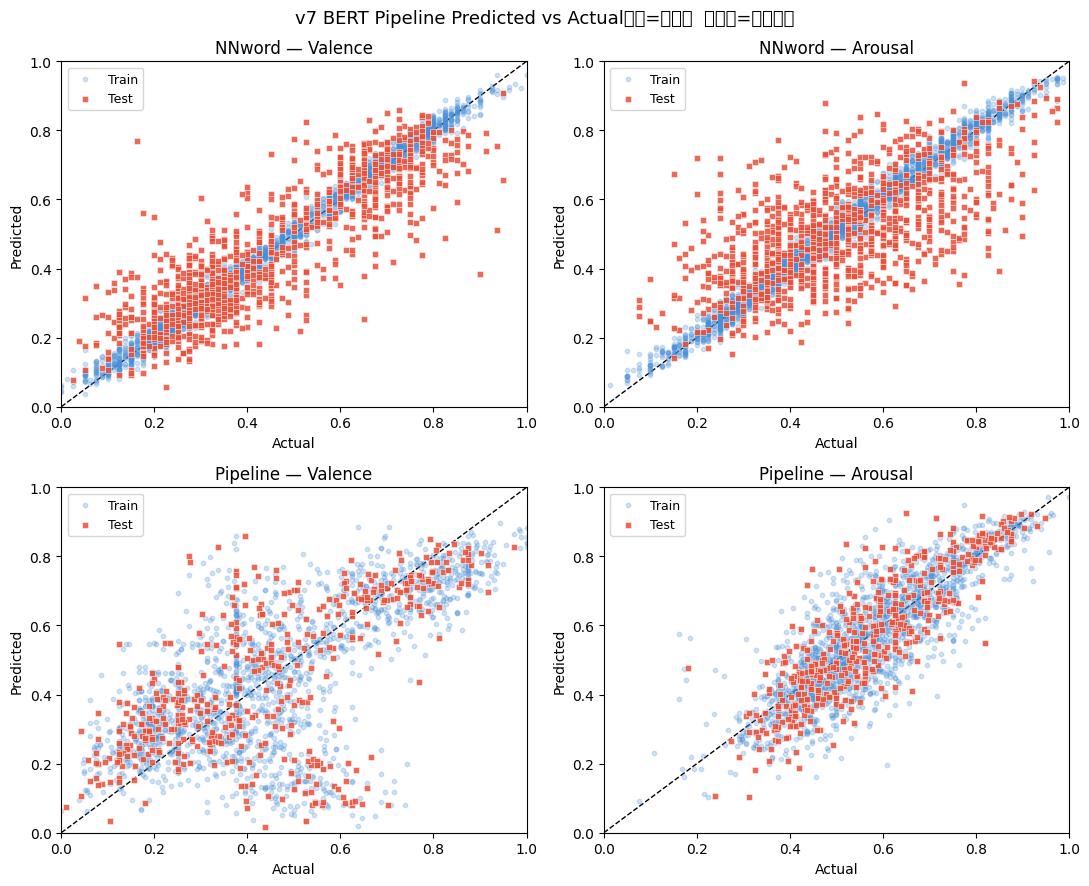

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('v7 BERT Pipeline Predicted vs Actual（藍=訓練集  紅方塊=測試集）', fontsize=13)

configs = [
    (axes[0,0], pv_trw, word_train_val, pv_tew, word_test_val, 'NNword — Valence',   '#4A90D9', '#E8503A'),
    (axes[0,1], pa_trw, word_train_aro, pa_tew, word_test_aro, 'NNword — Arousal',   '#4A90D9', '#E8503A'),
    (axes[1,0], pv_trm, phrase_train_val, pv_tem, phrase_test_val, 'Pipeline — Valence', '#4A90D9', '#E8503A'),
    (axes[1,1], pa_trm, phrase_train_aro, pa_tem, phrase_test_aro, 'Pipeline — Arousal', '#4A90D9', '#E8503A'),
]
for ax, ptr, gtr, pte, gte, title, c_tr, c_te in configs:
    ax.scatter(gtr, ptr, alpha=0.25, s=10, color=c_tr, label='Train', zorder=2)
    ax.scatter(gte, pte, alpha=0.85, s=20, color=c_te, marker='s',
               edgecolors='white', linewidths=0.4, label='Test', zorder=3)
    ax.plot([0,1],[0,1],'k--', linewidth=1, zorder=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()